# DataCo Supply Chain & Logistics Cost Optimization
**Objective:** Analyze delivery performance, quantify delay-related cost leakages, and build a category-wise risk matrix for executive strategy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean visual output
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)



Libraries imported successfully!


In [3]:
# Load the DataCo dataset (using ISO-8859-1 encoding for special characters)
df = pd.read_csv('data/DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')

# Select key analytical columns
cols_to_keep = [
    'Order Id', 'Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
    'Category Name', 'Department Name', 'Market', 'Order Region', 'Order Country', 'Shipping Mode'
]
df_clean = df[cols_to_keep].copy()

# Feature Engineering
df_clean['Delay_Days'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']
df_clean['Is_Delayed'] = np.where(df_clean['Delay_Days'] > 0, 1, 0)

# Financial Modeling: Estimate 5% late penalty fee on delayed order sales
df_clean['Late_Penalty_Cost'] = np.where(df_clean['Is_Delayed'] == 1, df_clean['Sales per customer'] * 0.05, 0)
df_clean['Adjusted_Profit'] = df_clean['Benefit per order'] - df_clean['Late_Penalty_Cost']

df_clean.head()

,Order Id,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Department Name,Market,Order Region,Order Country,Shipping Mode,Delay_Days,Is_Delayed,Late_Penalty_Cost,Adjusted_Profit
0,77202,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Southeast Asia,Indonesia,Standard Class,-1,0,0.000000,91.250000
1,75939,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Fitness,Pacific Asia,South Asia,India,Standard Class,1,1,15.567999,-264.657996
2,75938,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,Fitness,Pacific Asia,South Asia,India,Standard Class,0,0,0.000000,-247.779999
3,75937,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Oceania,Australia,Standard Class,-1,0,0.000000,22.860001
4,75936,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Fitness,Pacific Asia,Oceania,Australia,Standard Class,-2,0,0.000000,134.210007


In [4]:
# Aggregate key metrics
total_orders = len(df_clean)
total_revenue = df_clean['Sales per customer'].sum()
total_profit = df_clean['Benefit per order'].sum()
total_penalties = df_clean['Late_Penalty_Cost'].sum()
late_rate = df_clean['Late_delivery_risk'].mean() * 100

print(f"=== EXECUTIVE SUMMARY METRICS ===")
print(f"Total Orders Analyzed : {total_orders:,}")
print(f"Total Gross Revenue    : ${total_revenue:,.2f}")
print(f"Total Gross Profit     : ${total_profit:,.2f}")
print(f"Late Delivery Rate     : {late_rate:.2f}%")
print(f"Total Delay Penalty    : ${total_penalties:,.2f}")
print(f"Potential Savings (40% delay reduction): ${(total_penalties * 0.40):,.2f}")

=== EXECUTIVE SUMMARY METRICS ===
Total Orders Analyzed : 180,519
Total Gross Revenue    : $33,054,402.38
Total Gross Profit     : $3,966,902.97
Late Delivery Rate     : 54.83%
Total Delay Penalty    : $944,488.11
Potential Savings (40% delay reduction): $377,795.24


In [5]:
# Group by Category to find worst-performing segments
category_summary = df_clean.groupby('Category Name').agg(
    Total_Orders=('Order Id', 'count'),
    Total_Sales=('Sales per customer', 'sum'),
    Total_Gross_Profit=('Benefit per order', 'sum'),
    Total_Penalty_Loss=('Late_Penalty_Cost', 'sum'),
    Late_Delivery_Pct=('Late_delivery_risk', lambda x: x.mean() * 100)
).reset_index()

category_summary['Net_Profit'] = category_summary['Total_Gross_Profit'] - category_summary['Total_Penalty_Loss']

# Top 10 categories with highest delay cost leakages
top_leakage = category_summary.sort_values(by='Total_Penalty_Loss', ascending=False).head(10)

print("Top 10 Categories by Delay Cost Leakage:")
top_leakage[['Category Name', 'Total_Sales', 'Total_Penalty_Loss', 'Late_Delivery_Pct', 'Net_Profit']]

Top 10 Categories by Delay Cost Leakage:


,Category Name,Total_Sales,Total_Penalty_Loss,Late_Delivery_Pct,Net_Profit
18,Fishing,6.226935e+06,178415.361865,54.926407,577805.405325
12,Cleats,3.982857e+06,113778.819505,54.971284,380858.100286
9,Camping & Hiking,3.700784e+06,105310.257024,54.534198,322145.311081
10,Cardio Equipment,3.320251e+06,94275.974904,54.496677,288735.123581
47,Women's Apparel,2.828708e+06,80795.925000,54.556691,269625.104567
46,Water Sports,2.798044e+06,80121.344426,54.806950,245025.615612
30,Indoor/Outdoor Games,2.596454e+06,74379.298817,54.746606,244072.131737
34,Men's Footwear,2.598494e+06,73940.267446,54.486200,237962.552767
38,Shop By Sport,1.177186e+06,33886.585209,55.152950,95927.375106
13,Computers,5.953950e+05,15685.500000,50.678733,53971.310171


C:\Users\user\AppData\Local\Temp\ipykernel_23936\3304781134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


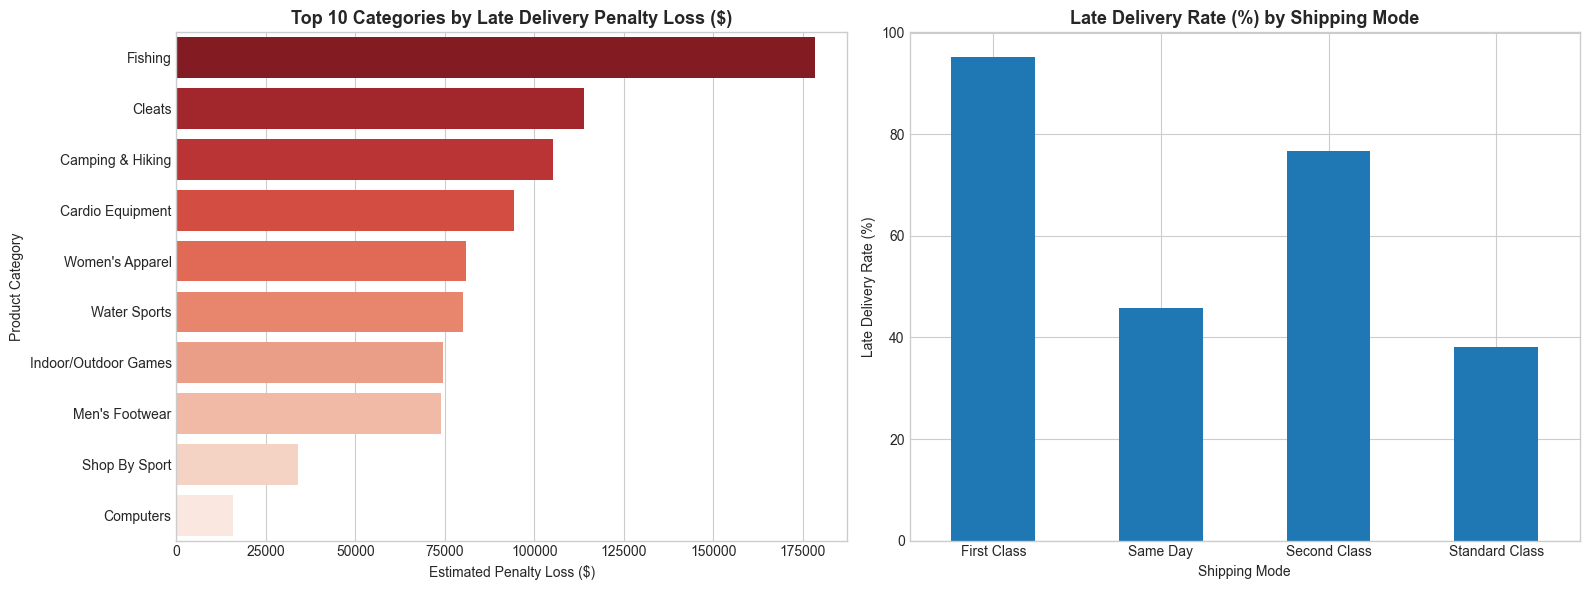

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Top 10 Categories by Delay Loss
sns.barplot(
    data=top_leakage, 
    y='Category Name', 
    x='Total_Penalty_Loss', 
    palette='Reds_r', 
    ax=axes[0]
)
axes[0].set_title('Top 10 Categories by Late Delivery Penalty Loss ($)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estimated Penalty Loss ($)')
axes[0].set_ylabel('Product Category')

# Chart 2: Shipping Mode vs Delay Risk
shipping_summary = df_clean.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
shipping_summary.plot(kind='bar', color='#1f77b4', ax=axes[1])
axes[1].set_title('Late Delivery Rate (%) by Shipping Mode', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Late Delivery Rate (%)')
axes[1].set_xlabel('Shipping Mode')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [7]:

category_summary.to_csv('category_summary.csv', index=False)
df_clean.to_csv('cleaned_supply_chain_data.csv', index=False)



In [8]:
import pulp

# Define linear programming problem: Minimize Total Logistics Cost
prob = pulp.LpProblem("Supply_Chain_Cost_Minimization", pulp.LpMinimize)

# Decision variables: Volume allocated to Shipping Mode i
modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']
costs = [10, 15, 25, 40]        # Example cost per unit
delay_risk = [0.40, 0.20, 0.05, 0.01]  # Delay probabilities

x = pulp.LpVariable.dicts("Volume", modes, lowBound=0, cat='Continuous')

# Objective Function: Minimize Cost
prob += pulp.lpSum([costs[i] * x[modes[i]] for i in range(4)])

# Constraints
prob += pulp.lpSum([x[m] for m in modes]) == 10000  # Total 10,000 units needed
prob += pulp.lpSum([delay_risk[i] * x[modes[i]] for i in range(4)]) <= 500  # Max 5% total delays allowed

prob.solve()
print("Optimal Volume Allocation:", {m: x[m].varValue for m in modes})

Optimal Volume Allocation: {'Standard Class': 0.0, 'Second Class': 0.0, 'First Class': 10000.0, 'Same Day': 0.0}
